Loading caption model blip-large...


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 5833.52it/s]


Loading CLIP model ViT-L-14/openai...
Loaded CLIP model and data in 3.71 seconds.


100%|██████████| 55/55 [00:00<00:00, 182.51it/s]


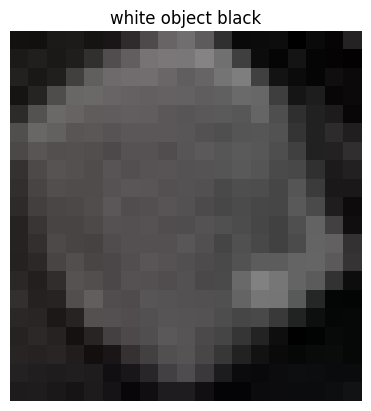

100%|██████████| 55/55 [00:00<00:00, 185.51it/s]


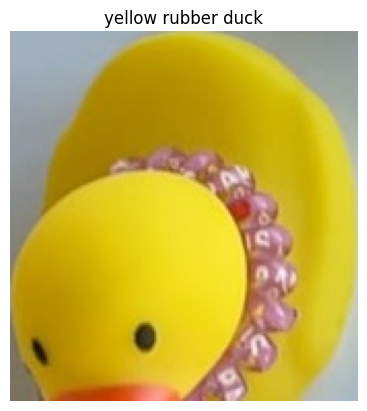

100%|██████████| 55/55 [00:00<00:00, 160.07it/s]


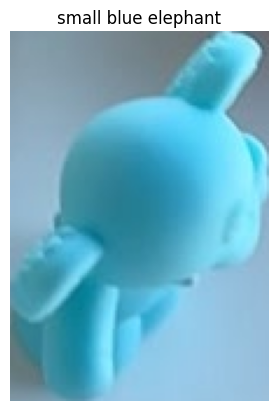

100%|██████████| 55/55 [00:00<00:00, 165.14it/s]


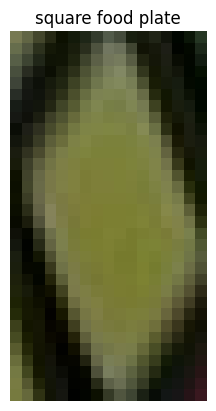

100%|██████████| 55/55 [00:00<00:00, 180.86it/s]


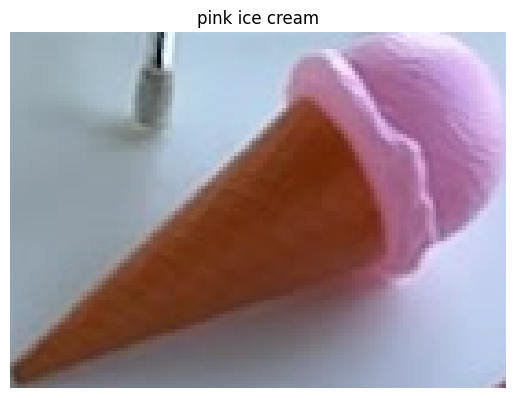

100%|██████████| 55/55 [00:00<00:00, 188.82it/s]


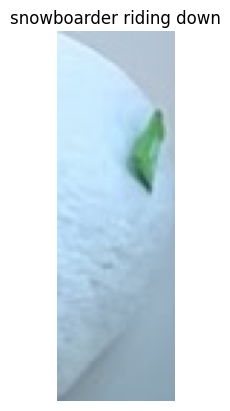

100%|██████████| 55/55 [00:00<00:00, 181.45it/s]


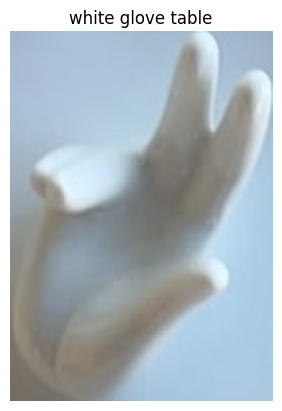

100%|██████████| 55/55 [00:00<00:00, 176.92it/s]


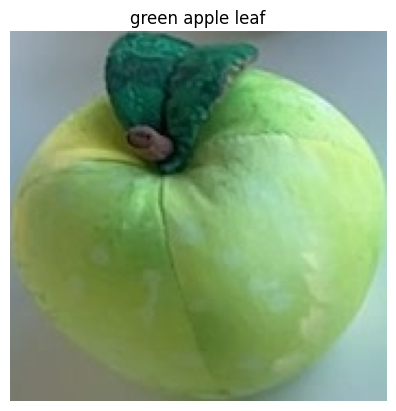

100%|██████████| 55/55 [00:00<00:00, 187.40it/s]


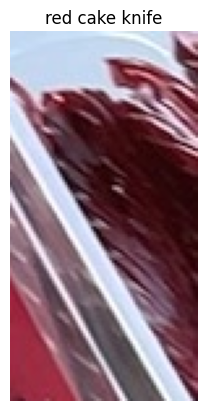

100%|██████████| 55/55 [00:00<00:00, 114.57it/s]


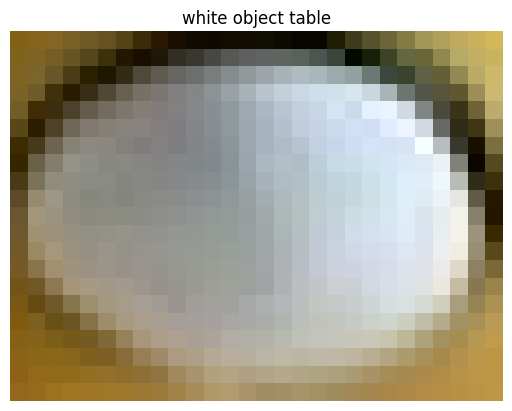

100%|██████████| 55/55 [00:00<00:00, 163.21it/s]


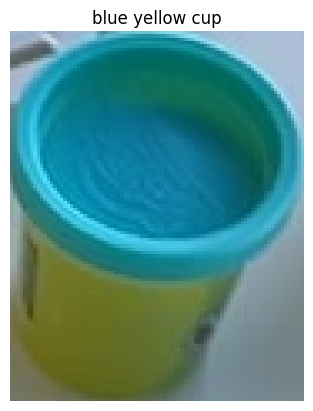

100%|██████████| 55/55 [00:00<00:00, 178.98it/s]


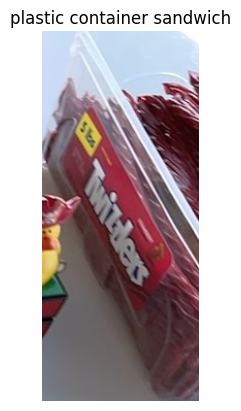

100%|██████████| 55/55 [00:00<00:00, 167.55it/s]


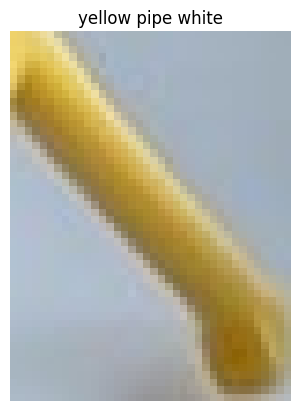

100%|██████████| 55/55 [00:00<00:00, 180.11it/s]


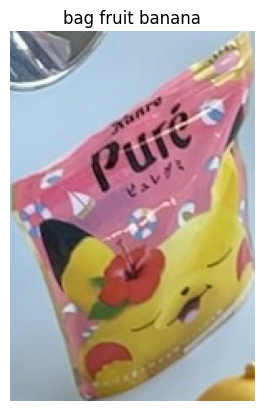

100%|██████████| 55/55 [00:00<00:00, 175.45it/s]


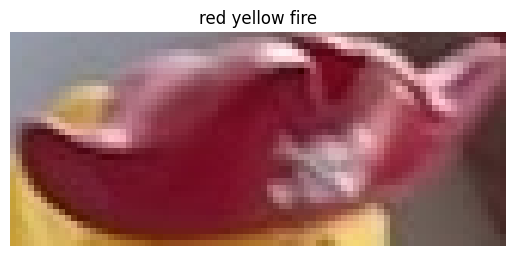

100%|██████████| 55/55 [00:00<00:00, 176.99it/s]


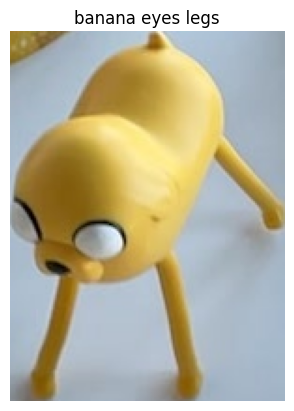

100%|██████████| 55/55 [00:00<00:00, 145.36it/s]


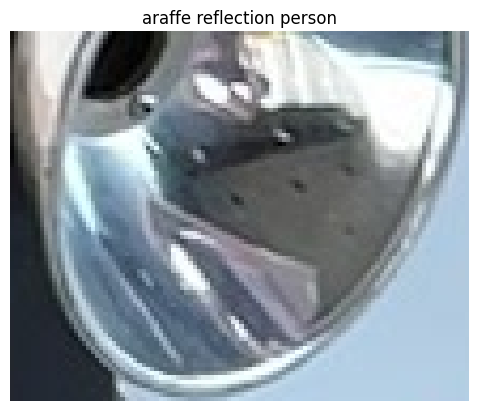

100%|██████████| 55/55 [00:00<00:00, 157.25it/s]


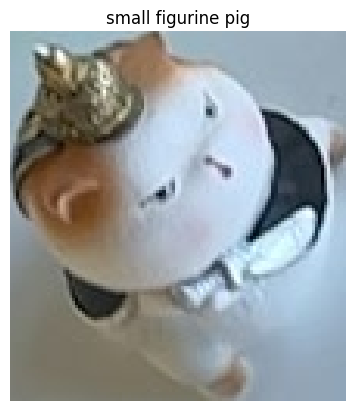

100%|██████████| 55/55 [00:00<00:00, 157.30it/s]


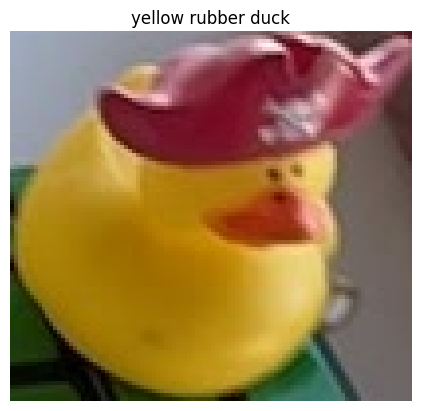

100%|██████████| 55/55 [00:00<00:00, 99.08it/s] 


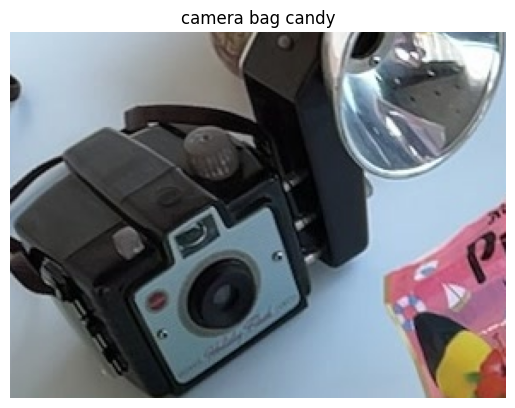

100%|██████████| 55/55 [00:00<00:00, 113.85it/s]


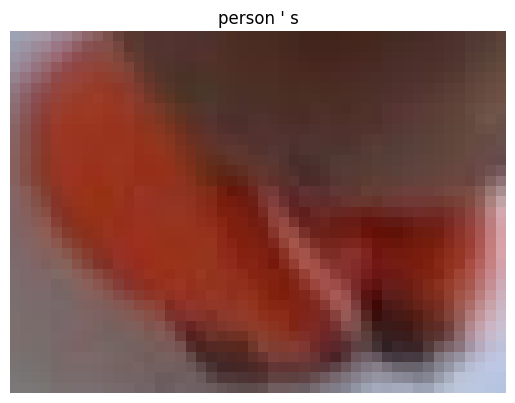

All captions: ['white object black', 'yellow rubber duck', 'small blue elephant', 'square food plate', 'pink ice cream', 'snowboarder riding down', 'white glove table', 'green apple leaf', 'red cake knife', 'white object table', 'blue yellow cup', 'plastic container sandwich', 'yellow pipe white', 'bag fruit banana', 'red yellow fire', 'banana eyes legs', 'araffe reflection person', 'small figurine pig', 'yellow rubber duck', 'camera bag candy', "person ' s"]


In [5]:
import os
import re
from PIL import Image
import torch
import matplotlib.pyplot as plt
from clip_interrogator import Config, Interrogator

# === Setup CLIP Interrogator ===
device = "cuda" if torch.cuda.is_available() else "cpu"
ci = Interrogator(Config(clip_model_name="ViT-L-14/openai", device=device))

save_folder = "/scratch/codepk37/anlpnerf/sam2/notebooks/mask_obj_figurines"

# stopwords to drop
STOPWORDS = {"there", "is", "a", "an", "the", "on", "with", "of", "and",
             "sitting", "close", "up", "in", "to", "from", "that", "this"}

def clean_caption(caption: str):
    words = re.split(r"[ ,]", caption.lower())
    words = [w.strip() for w in words if w.strip() and w not in STOPWORDS]
    return " ".join(words[:3])

captions = []

# === Loop and show ===
for file in os.listdir(save_folder):
    if not file.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    
    img_path = os.path.join(save_folder, file)
    image = Image.open(img_path).convert("RGB")
    
    # Get caption
    caption = ci.interrogate_fast(image)
    short_desc = clean_caption(caption)
    captions.append(short_desc)
    
    # Show image with caption
    plt.imshow(image)
    plt.axis("off")
    plt.title(short_desc, fontsize=12)
    plt.show()

print("All captions:", captions)
